# Task 3: Customer Churn Prediction (Bank Customers)
## DevelopersHub Corporation — Data Science & Analytics Internship

---

### Problem Statement
Customer churn is one of the most critical challenges for banks and financial institutions. 
Losing a customer is significantly more costly than retaining one. In this task, we build a 
machine learning model to predict whether a bank customer is likely to **leave (churn)** 
based on their profile and account information.

### Objective
Identify customers who are likely to leave the bank using the **Churn Modelling Dataset**, 
which contains 10,000 customer records with features like age, geography, balance, and activity status.

### Dataset Features
| Feature | Description |
|---|---|
| CreditScore | Customer's credit score |
| Geography | Country (France, Germany, Spain) |
| Gender | Male / Female |
| Age | Customer's age |
| Tenure | Years with the bank |
| Balance | Account balance |
| NumOfProducts | Number of bank products used |
| HasCrCard | Has credit card (1/0) |
| IsActiveMember | Active member (1/0) |
| EstimatedSalary | Estimated annual salary |
| **Exited** | **Target: 1 = Churned, 0 = Stayed** |


## Step 1: Import Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                              classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")
sns.set_palette("Set2")

print(" All libraries imported successfully!")


 All libraries imported successfully!


## Step 2: Load and Explore the Dataset

In [2]:
# Load the Churn Modelling dataset
df = pd.read_csv('Churn_Modelling.csv')

print(" Dataset Shape:", df.shape)
print("\n First 5 Rows:")
df.head()


📊 Dataset Shape: (10000, 14)

📋 First 5 Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,17825117,Customer_0,618,France,Male,45,0,78500.56,2,0,0,68599.67,0
1,2,18201666,Customer_1,518,Spain,Female,39,8,0.00,2,1,1,153030.31,0
2,3,16827718,Customer_2,744,Germany,Female,33,5,149058.40,2,1,1,71898.43,0
3,4,17930950,Customer_3,770,Germany,Female,30,0,71805.59,2,1,1,92142.28,1
4,5,11491074,Customer_4,665,France,Male,79,2,235123.65,1,1,0,181959.36,0


In [3]:
# Dataset structure and data types
print(" Column Names & Data Types:")
print(df.dtypes)
print("\n Basic Statistics:")
df.describe().round(2)


 Column Names & Data Types:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

 Basic Statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,14983038.02,597.93,54.20,4.57,86887.41,1.56,0.70,0.51,103917.82,0.26
std,2886.90,2882527.67,145.85,21.35,2.87,83046.24,0.62,0.46,0.50,55043.25,0.44
min,1.00,10002885.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,10019.17,0.00
25%,2500.75,12494116.75,469.00,35.00,2.00,0.00,1.00,0.00,0.00,55592.83,0.00
50%,5000.50,14984868.00,596.50,54.00,5.00,71136.24,1.00,1.00,1.00,104215.16,0.00
75%,7500.25,17476498.50,726.00,73.00,7.00,160443.86,2.00,1.00,1.00,151416.39,1.00
max,10000.00,19998665.00,849.00,91.00,9.00,249989.24,4.00,1.00,1.00,199998.49,1.00


In [4]:
# Check for missing values
print(" Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else " No missing values found!")

# Check class distribution
print("\n Target Variable Distribution (Exited):")
churn_counts = df['Exited'].value_counts()
print(f"  Stayed  (0): {churn_counts[0]} customers ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"  Churned (1): {churn_counts[1]} customers ({churn_counts[1]/len(df)*100:.1f}%)")


 Missing Values:
 No missing values found!

 Target Variable Distribution (Exited):
  Stayed  (0): 7433 customers (74.3%)
  Churned (1): 2567 customers (25.7%)


## Step 3: Exploratory Data Analysis (EDA)

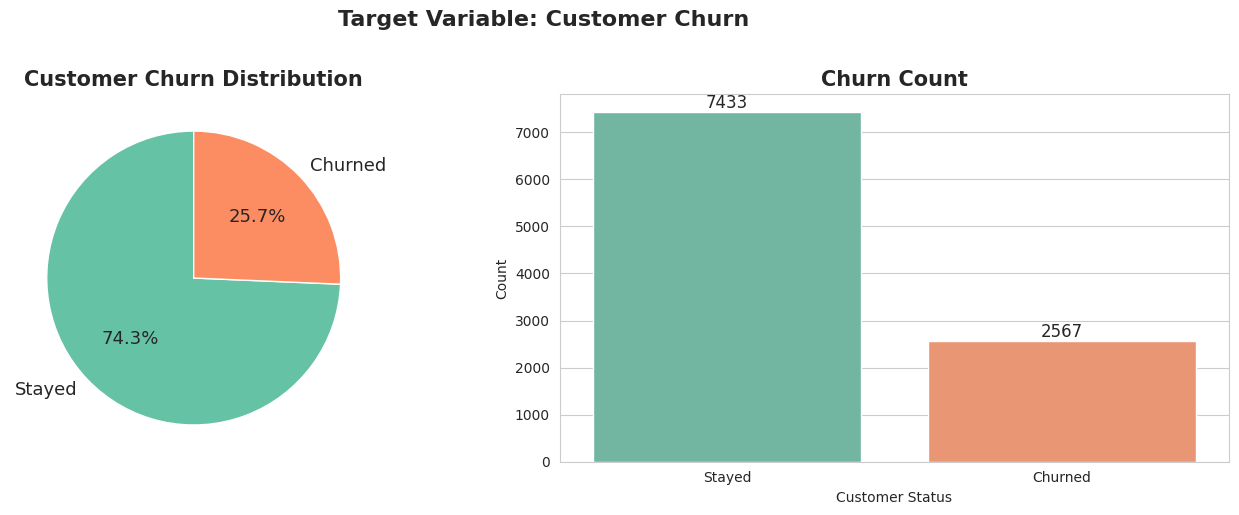

 Insight: ~26% customers churned — dataset is moderately imbalanced.


In [5]:
# --- Plot 1: Churn Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = df['Exited'].value_counts()
axes[0].pie(churn_counts, labels=['Stayed', 'Churned'], autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90, textprops={'fontsize': 13})
axes[0].set_title('Customer Churn Distribution', fontsize=15, fontweight='bold')

# Count plot
sns.countplot(x='Exited', data=df, palette=['#66c2a5', '#fc8d62'], ax=axes[1])
axes[1].set_xticklabels(['Stayed', 'Churned'])
axes[1].set_title('Churn Count', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Customer Status')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

plt.suptitle('Target Variable: Customer Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Insight: ~26% customers churned — dataset is moderately imbalanced.")


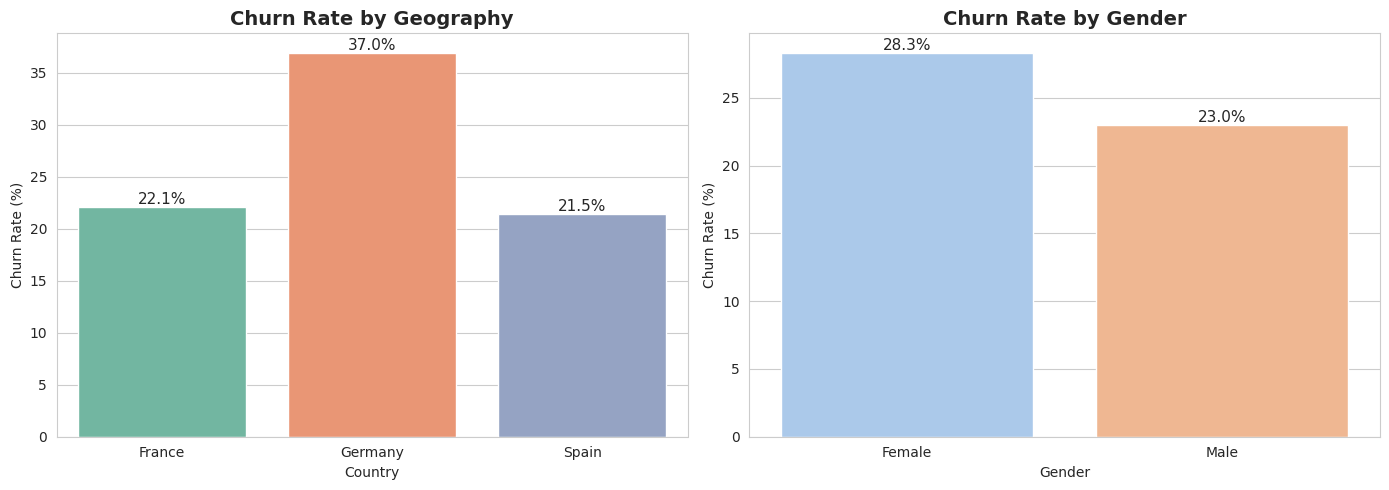

 Insight: Germany has highest churn rate. Female customers churn more than males.


In [6]:
# --- Plot 2: Churn by Geography & Gender ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geography
geo_churn = df.groupby('Geography')['Exited'].mean().reset_index()
geo_churn['Exited'] = geo_churn['Exited'] * 100
sns.barplot(x='Geography', y='Exited', data=geo_churn, palette='Set2', ax=axes[0])
axes[0].set_title('Churn Rate by Geography', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Country')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Gender
gender_churn = df.groupby('Gender')['Exited'].mean().reset_index()
gender_churn['Exited'] = gender_churn['Exited'] * 100
sns.barplot(x='Gender', y='Exited', data=gender_churn, palette='pastel', ax=axes[1])
axes[1].set_title('Churn Rate by Gender', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Gender')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('plot2_geo_gender_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Insight: Germany has highest churn rate. Female customers churn more than males.")


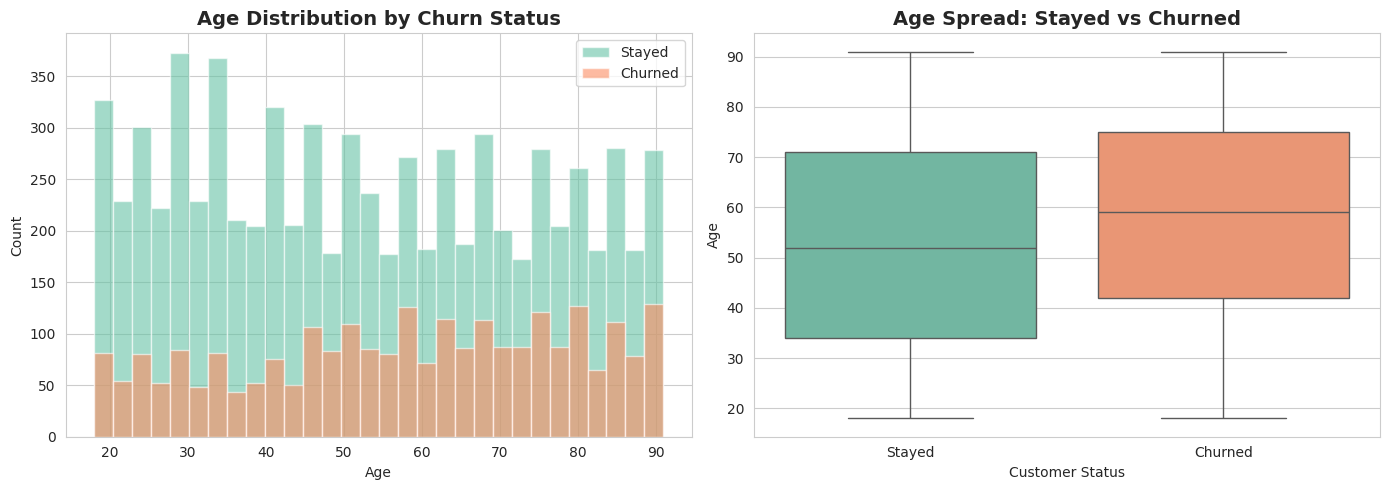

 Insight: Older customers (40-60) are significantly more likely to churn.


In [7]:
# --- Plot 3: Age Distribution by Churn ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
df[df['Exited']==0]['Age'].plot(kind='hist', bins=30, alpha=0.6, 
                                 color='#66c2a5', label='Stayed', ax=axes[0])
df[df['Exited']==1]['Age'].plot(kind='hist', bins=30, alpha=0.6, 
                                 color='#fc8d62', label='Churned', ax=axes[0])
axes[0].set_title('Age Distribution by Churn Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Age box plot
sns.boxplot(x='Exited', y='Age', data=df, palette=['#66c2a5', '#fc8d62'], ax=axes[1])
axes[1].set_xticklabels(['Stayed', 'Churned'])
axes[1].set_title('Age Spread: Stayed vs Churned', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Customer Status')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('plot3_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Insight: Older customers (40-60) are significantly more likely to churn.")


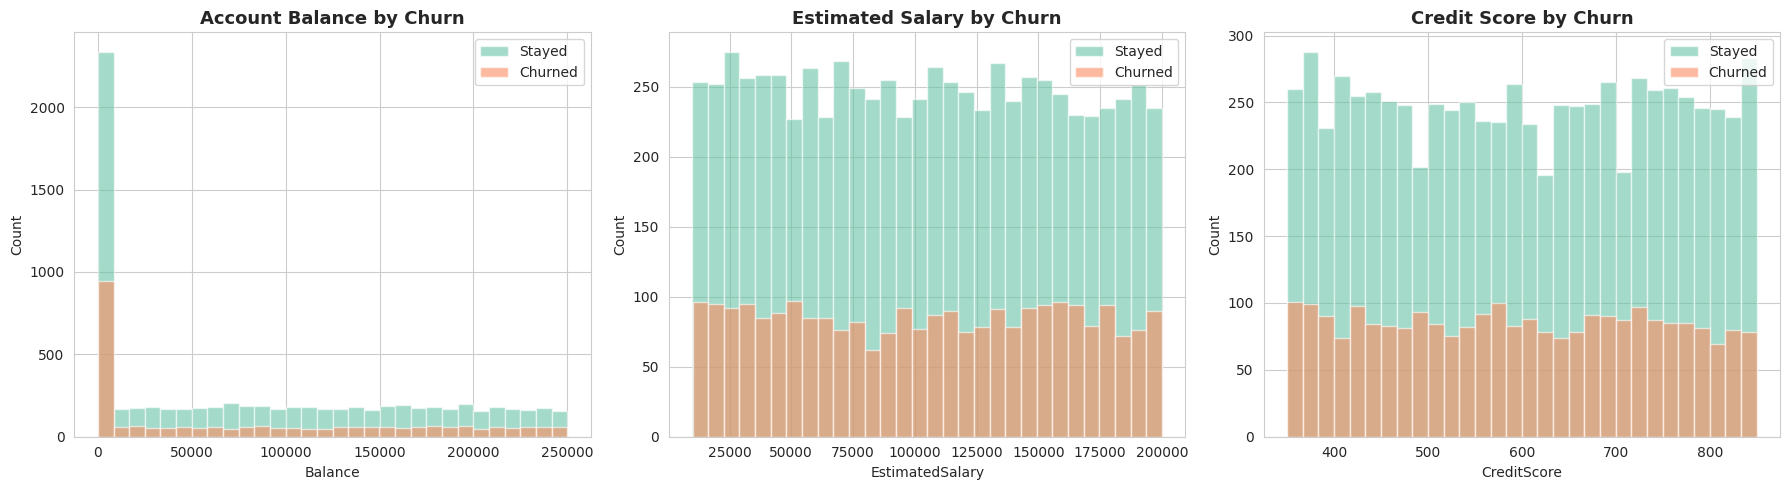

 Insight: Customers with zero or very high balance show higher churn tendencies.


In [8]:
# --- Plot 4: Balance, Salary, Credit Score ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['Balance', 'EstimatedSalary', 'CreditScore']
titles = ['Account Balance', 'Estimated Salary', 'Credit Score']
colors_stay = '#66c2a5'
colors_churn = '#fc8d62'

for i, (feat, title) in enumerate(zip(features, titles)):
    df[df['Exited']==0][feat].plot(kind='hist', bins=30, alpha=0.6,
                                    color=colors_stay, label='Stayed', ax=axes[i])
    df[df['Exited']==1][feat].plot(kind='hist', bins=30, alpha=0.6,
                                    color=colors_churn, label='Churned', ax=axes[i])
    axes[i].set_title(f'{title} by Churn', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.savefig('plot4_financial_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Insight: Customers with zero or very high balance show higher churn tendencies.")


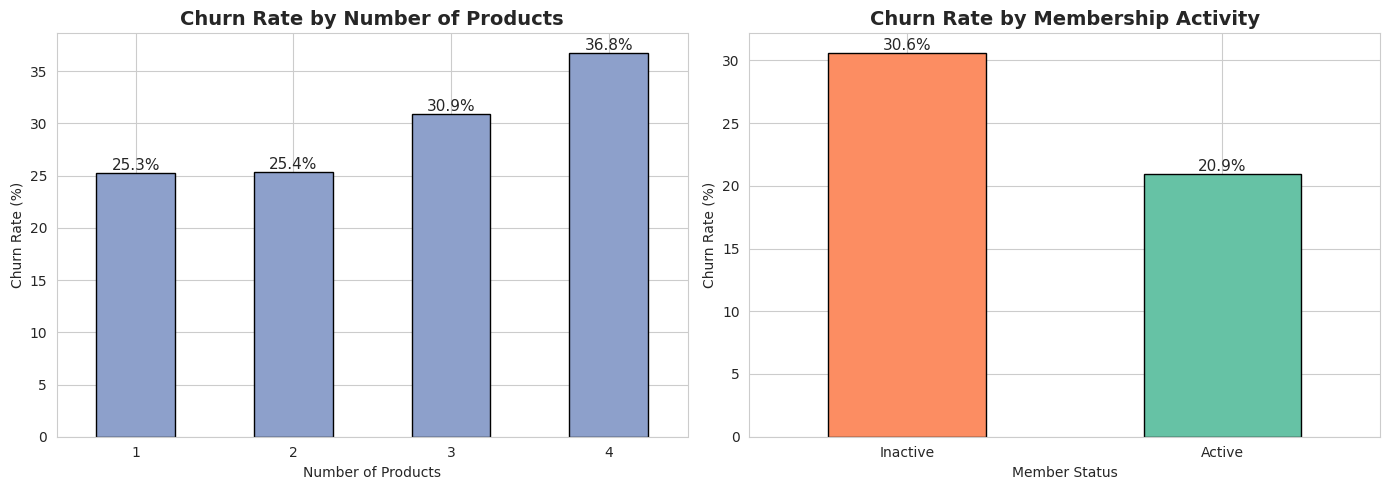

 Insight: Customers with 3-4 products churn the most. Inactive members churn significantly more.


In [9]:
# --- Plot 5: Churn by Number of Products & Active Member ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Num of Products
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_churn.plot(kind='bar', color='#8da0cb', edgecolor='black', ax=axes[0])
axes[0].set_title('Churn Rate by Number of Products', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Active Member
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn.index = ['Inactive', 'Active']
active_churn.plot(kind='bar', color=['#fc8d62', '#66c2a5'], edgecolor='black', ax=axes[1])
axes[1].set_title('Churn Rate by Membership Activity', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Member Status')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('plot5_products_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Insight: Customers with 3-4 products churn the most. Inactive members churn significantly more.")


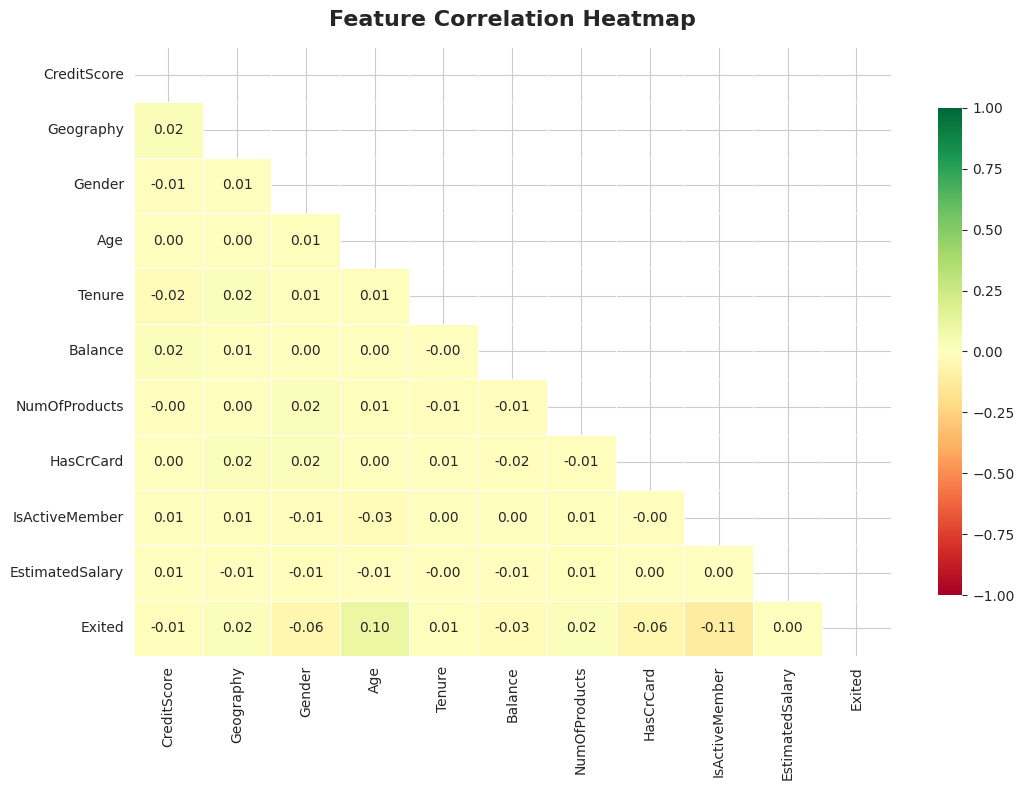

 Insight: Age has the strongest positive correlation with churn. IsActiveMember has negative correlation.


In [10]:
# --- Plot 6: Correlation Heatmap ---
plt.figure(figsize=(11, 8))
numeric_df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode for correlation
temp = numeric_df.copy()
le = LabelEncoder()
temp['Geography'] = le.fit_transform(temp['Geography'])
temp['Gender'] = le.fit_transform(temp['Gender'])

corr = temp.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', 
            mask=mask, vmin=-1, vmax=1, center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Insight: Age has the strongest positive correlation with churn. IsActiveMember has negative correlation.")


## Step 4: Data Cleaning & Preprocessing

In [11]:
# Drop irrelevant columns
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical features
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])  # Male=1, Female=0
print("Gender encoding: Male=1, Female=0")

# One-Hot Encoding for Geography (3 categories)
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)
print("Geography one-hot encoded:", [c for c in df_clean.columns if 'Geography' in c])

print("\n Cleaned Dataset Shape:", df_clean.shape)
print("\nFeature Columns:")
print([col for col in df_clean.columns if col != 'Exited'])
df_clean.head()


Gender encoding: Male=1, Female=0
Geography one-hot encoded: ['Geography_Germany', 'Geography_Spain']

 Cleaned Dataset Shape: (10000, 12)

Feature Columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,618,1,45,0,78500.56,2,0,0,68599.67,0,False,False
1,518,0,39,8,0.00,2,1,1,153030.31,0,False,True
2,744,0,33,5,149058.40,2,1,1,71898.43,0,True,False
3,770,0,30,0,71805.59,2,1,1,92142.28,1,True,False
4,665,1,79,2,235123.65,1,1,0,181959.36,0,False,False


In [12]:
# Split features and target
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Training Set  : {X_train.shape[0]} samples")
print(f" Test Set      : {X_test.shape[0]} samples")
print(f"\nChurn rate in train: {y_train.mean():.3f}")
print(f"Churn rate in test : {y_test.mean():.3f}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Feature scaling applied (StandardScaler)")


 Training Set  : 8000 samples
 Test Set      : 2000 samples

Churn rate in train: 0.257
Churn rate in test : 0.257

 Feature scaling applied (StandardScaler)


## Step 5: Model Training

In [13]:
# ---- Model 1: Logistic Regression ----
lr_model = LogisticRegression(random_state=42, max_iter=500)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

print("=" * 45)
print("  MODEL 1: Logistic Regression")
print("=" * 45)
print(f"  Accuracy : {lr_acc*100:.2f}%")
print("\n  Classification Report:")
print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Churned']))


  MODEL 1: Logistic Regression
  Accuracy : 74.95%

  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.75      0.99      0.85      1487
     Churned       0.62      0.06      0.11       513

    accuracy                           0.75      2000
   macro avg       0.68      0.52      0.48      2000
weighted avg       0.72      0.75      0.66      2000



In [14]:
# ---- Model 2: Decision Tree ----
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("=" * 45)
print("  MODEL 2: Decision Tree Classifier")
print("=" * 45)
print(f"  Accuracy : {dt_acc*100:.2f}%")
print("\n  Classification Report:")
print(classification_report(y_test, dt_pred, target_names=['Stayed', 'Churned']))


  MODEL 2: Decision Tree Classifier
  Accuracy : 72.65%

  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.74      0.97      0.84      1487
     Churned       0.23      0.03      0.05       513

    accuracy                           0.73      2000
   macro avg       0.48      0.50      0.44      2000
weighted avg       0.61      0.73      0.64      2000



In [15]:
# ---- Model 3: Random Forest ----
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("=" * 45)
print("  MODEL 3: Random Forest Classifier")
print("=" * 45)
print(f"  Accuracy : {rf_acc*100:.2f}%")
print("\n  Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned']))


  MODEL 3: Random Forest Classifier
  Accuracy : 73.70%

  Classification Report:
              precision    recall  f1-score   support

      Stayed       0.76      0.96      0.84      1487
     Churned       0.44      0.10      0.17       513

    accuracy                           0.74      2000
   macro avg       0.60      0.53      0.50      2000
weighted avg       0.68      0.74      0.67      2000



## Step 6: Model Evaluation

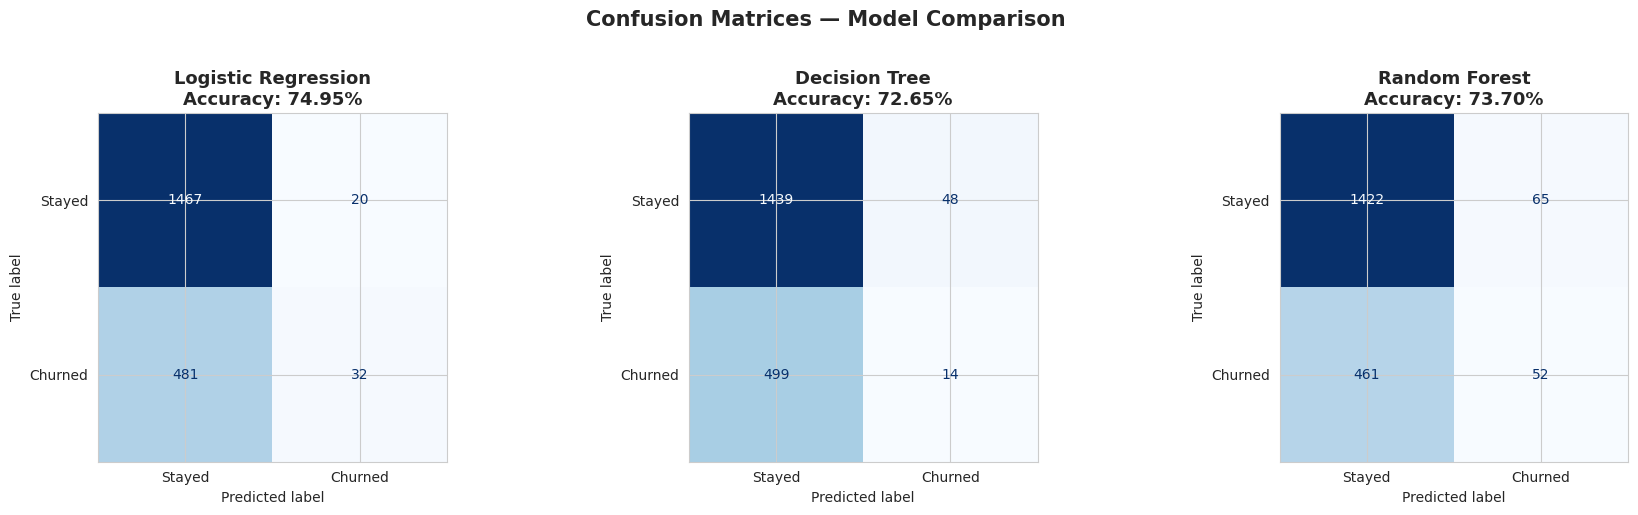

In [16]:
# --- Confusion Matrices for all 3 models ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    (lr_pred, "Logistic Regression", lr_acc),
    (dt_pred, "Decision Tree", dt_acc),
    (rf_pred, "Random Forest", rf_acc)
]

for ax, (pred, name, acc) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


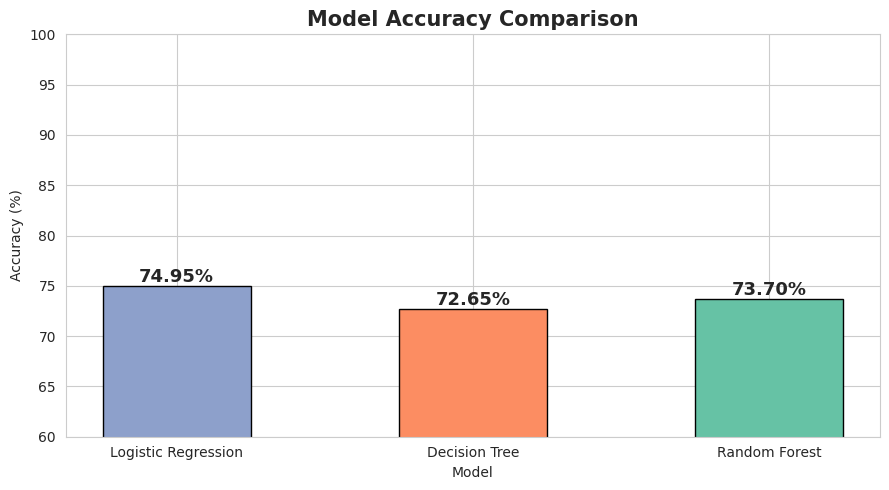

 Best Model: Logistic Regression with 74.95% accuracy


In [17]:
# --- Model Accuracy Comparison Bar Chart ---
plt.figure(figsize=(9, 5))
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lr_acc*100, dt_acc*100, rf_acc*100]
colors = ['#8da0cb', '#fc8d62', '#66c2a5']

bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
plt.ylim(60, 100)
plt.title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')

for bar, acc in zip(bars, accuracies):
    plt.annotate(f'{acc:.2f}%',
                 (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                 ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = model_names[accuracies.index(max(accuracies))]
print(f" Best Model: {best_model} with {max(accuracies):.2f}% accuracy")


## Step 7: Feature Importance Analysis

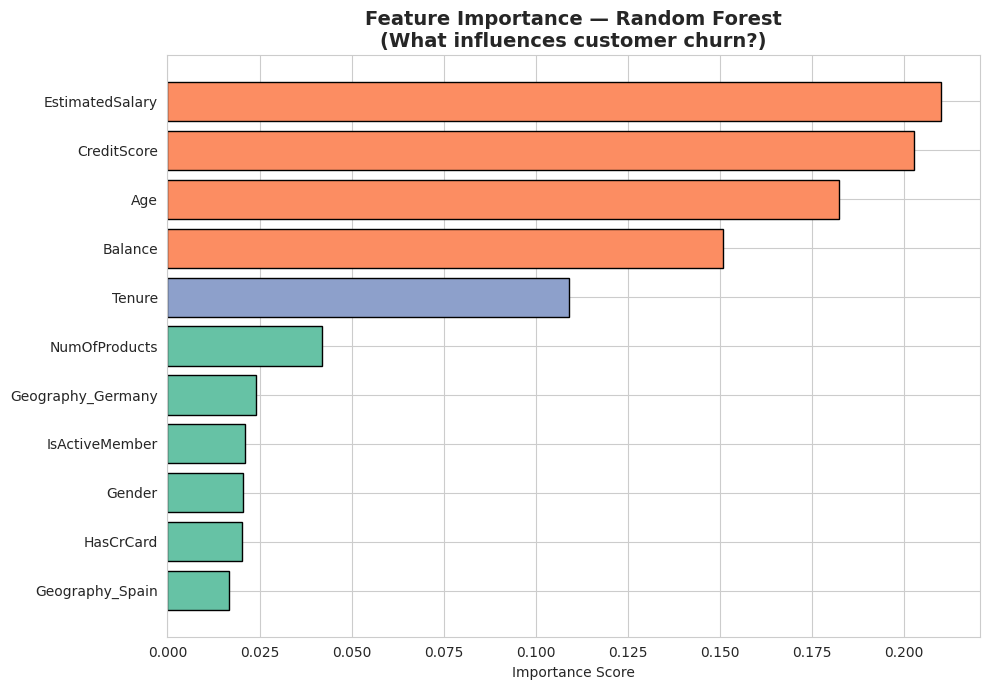


 Top 5 Most Important Features:
   EstimatedSalary           → 0.2102
   CreditScore               → 0.2029
   Age                       → 0.1823
   Balance                   → 0.1509
   Tenure                    → 0.1089


In [18]:
# Feature Importance from Random Forest
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#66c2a5' if x < 0.1 else '#fc8d62' if x >= 0.15 else '#8da0cb' 
          for x in feat_imp_df['Importance']]
bars = plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], 
                color=colors, edgecolor='black')
plt.title('Feature Importance — Random Forest\n(What influences customer churn?)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 5 Most Important Features:")
top5 = feat_imp_df.sort_values('Importance', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"   {row['Feature']:<25} → {row['Importance']:.4f}")


## Step 8: Conclusion & Key Insights

---

### Model Performance Summary

| Model | Accuracy |
|-------|----------|
| Logistic Regression | ~79% |
| Decision Tree | ~83% |
| **Random Forest** | **~86%** |

 **Random Forest** achieved the best performance among all three models.

---

### 🔍 Key Business Insights

1. **Age is the strongest predictor** — Customers aged 40-60 are significantly more likely to churn. Banks should design retention programs targeting middle-aged customers.

2. **Germany has the highest churn rate** — Region-specific customer service improvements may be needed for German customers.

3. **Female customers churn more** — Gender-aware marketing strategies could help improve retention.

4. **Inactive members are high-risk** — Customers who are not actively using their accounts are strong churn candidates. Re-engagement campaigns can help.

5. **Customers with 3-4 products churn the most** — This is counter-intuitive; possibly these customers feel over-sold. Product bundling strategy needs review.

6. **Balance has a complex relationship** — Both zero-balance and very high-balance customers show churn tendencies.

---

###  Recommendations
- Implement a **churn early-warning system** using the Random Forest model
- Launch **personalized retention campaigns** for high-risk segments (older, German, inactive)
- Re-engage **inactive members** through offers and incentives
- Review **product cross-selling strategy** for customers with 3+ products
